In [1]:
#[https://polymarket.com/event/strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583](https://polymarket.com/event/strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583)

SyntaxError: invalid syntax (1526758181.py, line 1)

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from polytrader.data import load_history, fetch_price_history
import pandas as pd

In [24]:
DAYS = 90
BUCKET_SECONDS = 120

markets = {
    "oct_31": "strait-of-hormuz-traffic-returns-to-normal-by-october-31-20260810151043583",
    "nov_30": "strait-of-hormuz-traffic-returns-to-normal-by-november-30-20260810151158765",
    "dec_31": "strait-of-hormuz-traffic-returns-to-normal-by-december-31",
}

histories = {}
series = {}

for name, slug in markets.items():
    history = fetch_price_history(
        event=slug,
        market=slug,
        days=DAYS,
        bucket_seconds=BUCKET_SECONDS,
    )
    histories[name] = history

    df = pd.DataFrame(history.data)

    # Support either timestamp/price or Polymarket's t/p field names.
    df = df.rename(columns={"t": "timestamp", "p": "price"})

    if df.empty:
        raise ValueError(f"No history returned for {name}")

    if not {"timestamp", "price"}.issubset(df.columns):
        raise ValueError(f"Unexpected columns for {name}: {df.columns.tolist()}")

    # Handle Unix timestamps in seconds or datetime/ISO strings.
    numeric_time = pd.to_numeric(df["timestamp"], errors="coerce")
    if numeric_time.notna().all():
        df["timestamp"] = pd.to_datetime(numeric_time, unit="s", utc=True)
    else:
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    df["price"] = pd.to_numeric(df["price"], errors="raise")

    s = (
        df.sort_values("timestamp")
        .drop_duplicates("timestamp", keep="last")
        .set_index("timestamp")["price"]
    )

    # Last observation in each 5-minute interval.
    # Label intervals by their END so observations precede the row timestamp.
    series[name] = s.resample(
        f"{BUCKET_SECONDS}s",
        closed="right",
        label="right",
    ).last()

    print(f"{name}: {len(df):,} observations")

prices = pd.concat(series, axis=1).sort_index()
prices.index.name = "timestamp"

# Exclude the current, unfinished interval.
cutoff = pd.Timestamp.now(tz="UTC").floor(f"{BUCKET_SECONDS}s")
prices = prices.loc[:cutoff]

# Keep missing observations visible; don't invent prices by filling gaps.
display(prices.tail(20).style.format("{:.2%}", na_rep="—"))

# Check how much overlapping data you have.
display(pd.DataFrame({
    "observations": prices.count(),
    "missing_buckets": prices.isna().sum(),
}))

aligned = prices.dropna().copy()
print(f"Complete overlapping rows: {len(aligned):,}")

oct_31: 5,469 observations
nov_30: 5,469 observations
dec_31: 5,469 observations


,oct_31,nov_30,dec_31
timestamp,,,
2026-09-26 08:40:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:42:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:44:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:46:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:48:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:50:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:52:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:54:00+00:00,5.50%,13.50%,21.50%
2026-09-26 08:56:00+00:00,5.50%,13.50%,21.50%


,observations,missing_buckets
oct_31,5469,1
nov_30,5468,2
dec_31,5468,2


Complete overlapping rows: 5,468


In [25]:
for early, late in pairs:
    available = prices[[early, late]].dropna()

    print(f"\n{early} / {late}")
    print("First:", available.index.min())
    print("Last: ", available.index.max())
    print("Rows: ", len(available))

# Inspect the exact period where you previously found violations.
display(
    prices.loc[
        "2026-08-11 09:00:00+00:00":
        "2026-08-11 10:30:00+00:00"
    ]
)


oct_31 / nov_30
First: 2026-09-18 19:00:00+00:00
Last:  2026-09-26 09:14:00+00:00
Rows:  5468

nov_30 / dec_31
First: 2026-09-18 19:00:00+00:00
Last:  2026-09-26 09:14:00+00:00
Rows:  5468

oct_31 / dec_31
First: 2026-09-18 19:00:00+00:00
Last:  2026-09-26 09:14:00+00:00
Rows:  5468


,oct_31,nov_30,dec_31
timestamp,,,


In [15]:
analysis = aligned.copy()

# Deadline spreads, expressed in percentage points.
analysis["nov_minus_oct_pp"] = (
    analysis["nov_30"] - analysis["oct_31"]
) * 100

analysis["dec_minus_nov_pp"] = (
    analysis["dec_31"] - analysis["nov_30"]
) * 100

# Implied conditional probability of occurrence between deadlines.
analysis["nov_given_not_oct"] = (
    (analysis["nov_30"] - analysis["oct_31"])
    / (1 - analysis["oct_31"]).replace(0, float("nan"))
)

analysis["dec_given_not_nov"] = (
    (analysis["dec_31"] - analysis["nov_30"])
    / (1 - analysis["nov_30"]).replace(0, float("nan"))
)

# Flag historical prices that violate the expected deadline ordering.
analysis["ordering_violation"] = (
    (analysis["oct_31"] > analysis["nov_30"])
    | (analysis["nov_30"] > analysis["dec_31"])
)

formats = {
    col: "{:.2%}"
    for col in [
        "oct_31", "nov_30", "dec_31",
        "nov_given_not_oct", "dec_given_not_nov",
    ]
}
formats.update({
    "nov_minus_oct_pp": "{:.2f}",
    "dec_minus_nov_pp": "{:.2f}",
})

display(analysis[analysis["ordering_violation"]].tail(20).style.format(formats, na_rep="—"))

,oct_31,nov_30,dec_31,nov_minus_oct_pp,dec_minus_nov_pp,nov_given_not_oct,dec_given_not_nov,ordering_violation
timestamp,,,,,,,,
2026-08-11 09:20:00+00:00,26.00%,50.00%,46.50%,24.00,-3.50,32.43%,-7.00%,True
2026-08-11 09:25:00+00:00,26.00%,50.00%,46.50%,24.00,-3.50,32.43%,-7.00%,True
2026-08-11 09:30:00+00:00,33.00%,52.00%,46.50%,19.00,-5.50,28.36%,-11.46%,True
2026-08-11 09:35:00+00:00,33.50%,52.00%,46.50%,18.50,-5.50,27.82%,-11.46%,True
2026-08-11 09:40:00+00:00,33.00%,52.00%,46.50%,19.00,-5.50,28.36%,-11.46%,True
2026-08-11 09:45:00+00:00,33.50%,52.00%,46.50%,18.50,-5.50,27.82%,-11.46%,True
2026-08-11 09:50:00+00:00,34.00%,52.00%,46.50%,18.00,-5.50,27.27%,-11.46%,True
2026-08-11 09:55:00+00:00,34.00%,51.50%,46.50%,17.50,-5.00,26.52%,-10.31%,True
2026-08-11 10:00:00+00:00,29.00%,51.00%,46.50%,22.00,-4.50,30.99%,-9.18%,True


In [27]:
import pandas as pd
from IPython.display import display

# Hypothetical total execution cost across BOTH legs, per share pair.
COST_PER_PAIR = 0.01  # 2 cents; also try 0, 0.005, 0.01, 0.05

pairs = [
    ("oct_31", "nov_30"),
    ("nov_30", "dec_31"),
    ("oct_31", "dec_31"),
]

expected_step = pd.Timedelta(seconds=BUCKET_SECONDS)
records = []

for early, late in pairs:
    pair = prices[[early, late]].sort_index().copy()

    pair["gross_edge"] = pair[early] - pair[late]
    pair["net_edge"] = pair["gross_edge"] - COST_PER_PAIR

    eligible = (
        pair[[early, late]].notna().all(axis=1)
        & (pair["net_edge"] > 1e-12)
    )

    # Missing rows or gaps break an episode.
    time_gap = pair.index.to_series().diff() > expected_step
    episode_id = (
        eligible.ne(eligible.shift(fill_value=False)) | time_gap
    ).cumsum()

    for _, episode in pair.loc[eligible].groupby(episode_id[eligible]):
        start = episode.index[0]
        end = episode.index[-1]

        records.append({
            "pair": f"{early} → {late}",
            "first_seen": start,
            "last_seen": end,
            "observed_span_min": (end - start).total_seconds() / 60,
            "observations": len(episode),
            "first_gross_edge_cents": episode["gross_edge"].iloc[0] * 100,
            "first_net_edge_cents": episode["net_edge"].iloc[0] * 100,
            "max_gross_edge_cents": episode["gross_edge"].max() * 100,
        })

episodes = pd.DataFrame(records)

if episodes.empty:
    print("No episodes exceed the assumed costs.")
else:
    episodes = episodes.sort_values(
        "first_net_edge_cents", ascending=False
    )
    display(episodes.head(30).style.format({
        "observed_span_min": "{:.1f}",
        "first_gross_edge_cents": "{:.2f}",
        "first_net_edge_cents": "{:.2f}",
        "max_gross_edge_cents": "{:.2f}",
    }))

No episodes exceed the assumed costs.


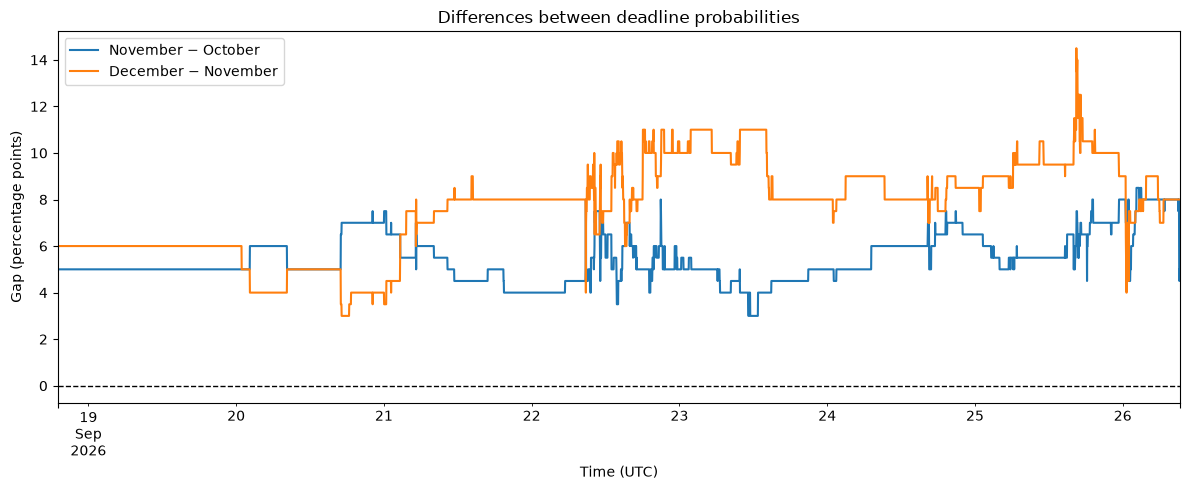

In [26]:
import matplotlib.pyplot as plt

spreads = pd.DataFrame({
    "November − October": prices["nov_30"] - prices["oct_31"],
    "December − November": prices["dec_31"] - prices["nov_30"],
}) * 100

ax = spreads.plot(figsize=(12, 5))
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set(
    title="Differences between deadline probabilities",
    xlabel="Time (UTC)",
    ylabel="Gap (percentage points)",
)
plt.tight_layout()
plt.show()